<center>
    <h1></h1>
    <h1><b>OCES 5303</b></h1>
    <h2>Extended Project</h2>
    <hr>
    <p>Jonas Mathisrud Sterud</p>
    <p>21335836</p>
</center>

<center>
    <h1></h1>
    <h3><i>Abstract</i></h3>
    <p>
    ...
    </p>
    <img src="./figures/cover.jpg" width="50%">
</center>

## Configuration

In [589]:
## Imports

import numpy as np
import pandas as pd
import plotly.io as pio
import matplotlib.pyplot as plt
import matplotlib as mpl
import cmocean
import torch
import cv2
import pickle
import random
import operator
import os

from sklearn.preprocessing import MinMaxScaler, StandardScaler, FunctionTransformer, SplineTransformer
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, KFold
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import median_absolute_error, mean_absolute_percentage_error, r2_score, confusion_matrix, ConfusionMatrixDisplay
from datetime import datetime
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from torch import nn
from torch.nn.utils.rnn import pad_sequence
from skorch import NeuralNetClassifier


## Configuration

seed = int(11111)
_ = random.seed(seed)
_ = np.random.seed(seed)
_ = torch.manual_seed(seed)
_ = torch.backends.cudnn.deterministic = True
_ = torch.backends.cudnn.benchmark = False

## Colors

RED = "#FF6200"
RED_TRANSPARENT = "#FF6200A7"
GREEN = "#00B755"
GREEN_TRANSPARENT = "#00B755A7"
BLUE = "#0048FF"
BLUE_TRANSPARENT = "#0048FFA7"
GREY = "#959595"
GREY_TRANSPARENT = "#959595A7"


# Load and parse the data

In [590]:
TRAIN_PNG_DIR = "./data/TRAIN_png/TRAIN_png"
TEST_PNG_DIR = "./data/TEST_png/TEST_png"
LABELS_TRAIN_DIR = "./data/LABELS_TRAIN/train"
TRAIN_IMAGES_PKL_DIR = "./data/train_images_pkl"
TEST_IMAGES_PKL_DIR = "./data/test_images_pkl"

# Load PKLs

def load_pkl(directory: str) -> dict:
    out = {}

    with os.scandir(directory) as dirs:
        for dir in dirs:
            date = datetime.strptime(dir.path.split("/")[-1], "%Y%m%d")

            with os.scandir(dir) as files:
                for file in files:
                    if file.is_file():
                        name = file.path.split("/")[-1].removesuffix(".pkl")
                        if (out.get(name) == None): out[name] = {}
                        #if (name == "eddy_centre"): # Only Eddy centres for now
                        with open(file.path, "rb") as rb_file:
                            try:
                                data = pickle.load(rb_file)
                                out[name][date] = data
                            except Exception as e:
                                print(e)
    
    return out

# Load labels
def load_labels(directory: str) -> dict:
    out = {}

    with os.scandir(directory) as files:
        for file in files:
            date = datetime.strptime(file.path.split("_")[-1].removesuffix(".csv"), "%Y%m%d")
            labels = pd.read_csv(file.path, header=None)

            out[date] = labels

    return out

# Load PNGs

def load_pngs(directory: str) -> pd.DataFrame:
    out = {}

    with os.scandir(directory) as files:
        for file in files:
            if file.is_file:
                (category, date, number) = file.path.split("/")[-1].removesuffix(".png").split("_")
                category = category
                date = datetime.strptime(date, "%Y%m%d")
                number = int(number)

                if out.get(category) == None:
                    out[category] = {}

                if out[category].get(date) == None:
                    out[category][date] = {}

                out[category][date][number] = cv2.imread(file.path, cv2.IMREAD_GRAYSCALE)

    for category in out.keys():
        for date in out[category].keys():
            out[category][date] = list(map(lambda kv: kv[1], sorted(out[category][date].items())))

    return pd.DataFrame(out)

# Load

df_png_train = load_pngs(TRAIN_PNG_DIR)

train_pkl_mapping = load_pkl(TRAIN_IMAGES_PKL_DIR)
train_labels_mapping = load_labels(LABELS_TRAIN_DIR)

df_png_test = load_pngs(TEST_PNG_DIR)
test_pkl_mapping = load_pkl(TEST_IMAGES_PKL_DIR)

# Format train PKLs

df_eddy_centre_train = pd.DataFrame(train_pkl_mapping["eddy_centre"].items()).set_index(0).rename(columns={ 1 : "EDDY_CENTRE"})
df_eddy_position_train = pd.DataFrame(train_pkl_mapping["eddy_position"].items()).set_index(0).rename(columns={ 1 : "EDDY_POSITION"})

df_eddy_latitude_train = pd.DataFrame(train_pkl_mapping["lat_contour_eddy"].items()).set_index(0).rename(columns={ 1 : "EDDY_LATITUDE" })
df_eddy_longitude_train = pd.DataFrame(train_pkl_mapping["lon_contour_eddy"].items()).set_index(0).rename(columns={ 1 : "EDDY_LONGITUDE" })

df_sst_latitude_train = pd.DataFrame(map(lambda v0: (v0[0], list(map(lambda v1: v1.compressed(), v0[1]))), train_pkl_mapping["lat_SST"].items())).set_index(0).rename(columns={ 1 : "SST_LATITUDE"})
df_sst_longitude_train = pd.DataFrame(map(lambda v0: (v0[0], list(map(lambda v1: v1.compressed(), v0[1]))), train_pkl_mapping["lon_SST"].items())).set_index(0).rename(columns={ 1 : "SST_LONGITUDE"})

df_chla_latitude_train = pd.DataFrame(map(lambda v0: (v0[0], list(map(lambda v1: v1.compressed(), v0[1]))), train_pkl_mapping["lat_CHLA"].items())).set_index(0).rename(columns={ 1 : "CHLA_LATITUDE"})
df_chla_longitude_train = pd.DataFrame(map(lambda v0: (v0[0], list(map(lambda v1: v1.compressed(), v0[1]))), train_pkl_mapping["lon_CHLA"].items())).set_index(0).rename(columns={ 1 : "CHLA_LONGITUDE"})

df_sla_latitude_train = pd.DataFrame(map(lambda v0: (v0[0], list(map(lambda v1: v1[0], v0[1]))), train_pkl_mapping["lat_sealevel"].items())).set_index(0).rename(columns={ 1 : "SLA_LATITUDE"})
df_sla_longitude_train = pd.DataFrame(map(lambda v0: (v0[0], list(map(lambda v1: v1[0], v0[1]))), train_pkl_mapping["lon_sealevel"].items())).set_index(0).rename(columns={ 1 : "SLA_LONGITUDE"})

df_labels_train = pd.DataFrame(map(lambda kv: (kv[0], kv[1].values.flatten()), train_labels_mapping.items())).set_index(0).rename(columns={ 1: "LABEL"})

# Format test PKLs

df_eddy_centre_test = pd.DataFrame(test_pkl_mapping["eddy_centre"].items()).set_index(0).rename(columns={ 1 : "EDDY_CENTRE"})
df_eddy_position_test = pd.DataFrame(test_pkl_mapping["eddy_position"].items()).set_index(0).rename(columns={ 1 : "EDDY_POSITION"})

df_eddy_latitude_test = pd.DataFrame(test_pkl_mapping["lat_contour_eddy"].items()).set_index(0).rename(columns={ 1 : "EDDY_LATITUDE" })
df_eddy_longitude_test = pd.DataFrame(test_pkl_mapping["lon_contour_eddy"].items()).set_index(0).rename(columns={ 1 : "EDDY_LONGITUDE" })

df_sst_latitude_test = pd.DataFrame(map(lambda v0: (v0[0], list(map(lambda v1: v1.compressed(), v0[1]))), test_pkl_mapping["lat_SST"].items())).set_index(0).rename(columns={ 1 : "SST_LATITUDE"})
df_sst_longitude_test = pd.DataFrame(map(lambda v0: (v0[0], list(map(lambda v1: v1.compressed(), v0[1]))), test_pkl_mapping["lon_SST"].items())).set_index(0).rename(columns={ 1 : "SST_LONGITUDE"})

df_chla_latitude_test = pd.DataFrame(map(lambda v0: (v0[0], list(map(lambda v1: v1.compressed(), v0[1]))), test_pkl_mapping["lat_CHLA"].items())).set_index(0).rename(columns={ 1 : "CHLA_LATITUDE"})
df_chla_longitude_test = pd.DataFrame(map(lambda v0: (v0[0], list(map(lambda v1: v1.compressed(), v0[1]))), test_pkl_mapping["lon_CHLA"].items())).set_index(0).rename(columns={ 1 : "CHLA_LONGITUDE"})

df_sla_latitude_test = pd.DataFrame(map(lambda v0: (v0[0], list(map(lambda v1: v1[0], v0[1]))), test_pkl_mapping["lat_sealevel"].items())).set_index(0).rename(columns={ 1 : "SLA_LATITUDE"})
df_sla_longitude_test = pd.DataFrame(map(lambda v0: (v0[0], list(map(lambda v1: v1[0], v0[1]))), test_pkl_mapping["lon_sealevel"].items())).set_index(0).rename(columns={ 1 : "SLA_LONGITUDE"})

df_labels_test = pd.DataFrame(map(lambda kv: (kv[0], kv[1]), test_pkl_mapping["eddy_labels"].items())).set_index(0).rename(columns={ 1: "LABEL"})

# Combine
frames_train = [df_png_train, df_eddy_centre_train, df_eddy_latitude_train, df_eddy_longitude_train, df_sst_latitude_train, df_sst_longitude_train, df_chla_latitude_train, df_chla_longitude_train, df_sla_latitude_train, df_sla_longitude_train, df_labels_train]
frames_test = [df_png_test, df_eddy_centre_test, df_eddy_latitude_test, df_eddy_longitude_test, df_sst_latitude_test, df_sst_longitude_test, df_chla_latitude_test, df_chla_longitude_test, df_sla_latitude_test, df_sla_longitude_test, df_labels_test]

df_train = pd.concat(frames_train, axis=1, sort=False)
df_test = pd.concat(frames_test, axis=1, sort=False)

unpickling stack underflow


In [591]:
df_train = df_train.explode(list(df_train.columns)).reset_index(names=["DATE"])
df_test = df_test.explode(list(df_test.columns)).reset_index(names=["DATE"])

In [592]:
df_train

,DATE,EDDY,SST,SLA,CHLA,EDDY_CENTRE,EDDY_LATITUDE,EDDY_LONGITUDE,SST_LATITUDE,SST_LONGITUDE,CHLA_LATITUDE,CHLA_LONGITUDE,SLA_LATITUDE,SLA_LONGITUDE,LABEL
0,2017-05-22,"[[0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, ...","[[178, 181, 189, 198, 206, 212, 217, 217, 217,...","[[0, 31, 90, 153, 196, 207, 189, 166], [26, 48...","[[0, 0, 0, 0, 0, 0, 0, 255, 255, 255, 255, 255...","[nan, nan]",NaN,NaN,"[24.875, 24.925, 24.975, 25.025, 25.075, 25.12...","[309.875, 309.925, 309.975, 310.025, 310.075, ...","[26.645832, 26.604164, 26.562498, 26.520832, 2...","[309.8542, 309.89584, 309.9375, 309.9792, 310....","[24.875, 24.875, 24.875, 24.875, 24.875, 24.87...","[309.875, 310.125, 310.375, 310.625, 310.875, ...",0
1,2017-05-22,"[[0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, ...","[[228, 233, 233, 231, 228, 220, 213, 206, 199,...","[[14, 15, 13, 10, 10, 11, 14, 17], [15, 16, 15...","[[255, 255, 255, 255, 255, 255, 255, 255, 255,...","[nan, nan]",NaN,NaN,"[24.875, 24.925, 24.975, 25.025, 25.075, 25.12...","[310.875, 310.925, 310.975, 311.025, 311.075, ...","[26.645832, 26.604164, 26.562498, 26.520832, 2...","[310.8542, 310.89584, 310.9375, 310.9792, 311....","[24.875, 24.875, 24.875, 24.875, 24.875, 24.87...","[310.875, 311.125, 311.375, 311.625, 311.875, ...",0
2,2017-05-22,"[[0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, ...","[[186, 180, 174, 168, 162, 153, 147, 138, 126,...","[[21, 18, 17, 17, 17, 17, 16, 17], [19, 16, 15...","[[255, 255, 255, 255, 255, 255, 255, 255, 255,...","[nan, nan]",NaN,NaN,"[24.875, 24.925, 24.975, 25.025, 25.075, 25.12...","[330.875, 330.925, 330.975, 331.025, 331.075, ...","[26.645832, 26.604164, 26.562498, 26.520832, 2...","[330.8542, 330.89584, 330.9375, 330.9792, 331....","[24.875, 24.875, 24.875, 24.875, 24.875, 24.87...","[330.875, 331.125, 331.375, 331.625, 331.875, ...",0
3,2017-05-22,"[[0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, ...","[[221, 228, 230, 228, 219, 212, 207, 210, 218,...","[[0, 27, 66, 109, 156, 202, 233, 246], [74, 11...","[[255, 255, 255, 255, 255, 255, 255, 255, 255,...","[nan, nan]",NaN,NaN,"[25.875, 25.925, 25.975, 26.025, 26.075, 26.12...","[294.875, 294.925, 294.975, 295.025, 295.075, ...","[27.645832, 27.604164, 27.562498, 27.520832, 2...","[294.8542, 294.89584, 294.9375, 294.9792, 295....","[25.875, 25.875, 25.875, 25.875, 25.875, 25.87...","[294.875, 295.125, 295.375, 295.625, 295.875, ...",0
4,2017-05-22,"[[0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, ...","[[247, 251, 251, 250, 245, 243, 241, 245, 248,...","[[140, 172, 194, 203, 216, 240, 255, 248], [17...","[[255, 255, 255, 255, 255, 255, 255, 255, 255,...","[nan, nan]",NaN,NaN,"[25.875, 25.925, 25.975, 26.025, 26.075, 26.12...","[295.875, 295.925, 295.975, 296.025, 296.075, ...","[27.645832, 27.604164, 27.562498, 27.520832, 2...","[295.8542, 295.89584, 295.9375, 295.9792, 296....","[25.875, 25.875, 25.875, 25.875, 25.875, 25.87...","[295.875, 296.125, 296.375, 296.625, 296.875, ...",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4837,2017-05-09,"[[0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, ...","[[196, 190, 182, 171, 159, 150, 145, 145, 148,...","[[173, 90, 27, 0, 9, 47, 96, 118], [155, 81, 3...","[[255, 255, 255, 255, 255, 255, 255, 255, 255,...","[290.7696, 31.481155]","[31.22, 31.25, 31.269999, 31.31, 31.33, 31.369...","[290.62, 290.61, 290.6, 290.58, 290.57, 290.55...","[30.475, 30.525, 30.575, 30.625, 30.675, 30.72...","[289.775, 289.825, 289.875, 289.925, 289.975, ...","[32.479164, 32.4375, 32.395832, 32.354164, 32....","[289.77084, 289.8125, 289.8542, 289.89584, 289...","[30.375, 30.375, 30.375, 30.375, 30.375, 30.37...","[289.875, 290.125, 290.375, 290.625, 290.875, ...",2
4838,2017-05-09,"[[0, 0, 0, 0, 0, 0, 0, 0], [0, 0, 0, 0, 0, 0, ...","[[218, 216, 212, 208, 203, 202, 204, 208, 211,...","[[201, 176, 153, 140, 142, 150, 158, 167], [18...","[[255, 255, 0, 255, 255, 255, 255, 255, 255, 2...","[322.71695, 32.768536]","[32.36, 32.37, 32.38, 32.38, 32.39, 32.42, 32....","[322.62, 322.43, 322.41, 322.39, 3

# Print various information about the data

In [593]:
# Date range

range_train = sorted(df_train[["EDDY", "SST", "SLA", "CHLA"]].index)
range_test = sorted(df_test[["EDDY", "SST", "SLA", "CHLA"]].index)

print(f"Train date range: From {range_train[0]} to {range_train[-1]}")
print(f"Test date range: From {range_test[0]} to {range_test[-1]}")

Train date range: From 0 to 4841
Test date range: From 0 to 4198


In [594]:
# # Train sizes

# eddy_size_set_train = set(map(lambda v: len(v), df_train[["EDDY"]].to_numpy()[0][0]))
# sst_size_set_train = set(map(lambda v: len(v), df_train[["SST"]].to_numpy()[0]))
# sla_size_set_train = set(map(lambda v: len(v), df_train[["SLA"]].to_numpy()[0]))
# chla_size_set_train = set(map(lambda v: len(v), df_train[["CHLA"]].to_numpy()[0]))

# eddy_size_train = df_train["EDDY"].apply(len).values
# sst_size_train = df_train["SST"].apply(len).values
# sla_size_train = df_train["SLA"].apply(len).values
# chla_size_train = df_train["CHLA"].apply(len).values

# # Test sizes

# eddy_size_set_test = set(map(lambda v: len(v), df_test[["EDDY"]].to_numpy()[0][0]))
# sst_size_set_test = set(map(lambda v: len(v), df_test[["SST"]].to_numpy()[0]))
# sla_size_set_test = set(map(lambda v: len(v), df_test[["SLA"]].to_numpy()[0]))
# chla_size_set_test = set(map(lambda v: len(v), df_test[["CHLA"]].to_numpy()[0]))

# eddy_size_test = df_test["EDDY"].apply(len).values
# sst_size_test = df_test["SST"].apply(len).values
# sla_size_test = df_test["SLA"].apply(len).values
# chla_size_test = df_test["CHLA"].apply(len).values

# # Print

# print("# TRAIN\n")
# print(f"EDDY sample sizes: {eddy_size_train}\nSST sample sizes: {sst_size_train}\nSLA sample sizes: {sla_size_train}\nCHLA sample sizes: {chla_size_train}\n")
# print(f"EDDY sample sizes min: {min(eddy_size_train)}\nSST sample sizes min: {min(sst_size_train)}\nSLA sample sizes min: {min(sla_size_train)}\nCHLA sample  sizes min: {min(chla_size_train)}\n")
# print(f"EDDY sample sizes max: {max(eddy_size_train)}\nSST sample sizes max: {max(sst_size_train)}\nSLA sample sizes max: {max(sla_size_train)}\nCHLA sample  sizes max: {max(chla_size_train)}\n")
# print(f"EDDY total sample size: {sum(eddy_size_train)}\nSST total sample size: {sum(sst_size_train)}\nSLA total sample size: {sum(sla_size_train)}\nCHLA total sample size: {sum(chla_size_train)}\n")
# print(f"EDDY set: {(eddy_size_set_train)}\nSST set: {(sst_size_set_train)}\nSLA set: {(sst_size_set_train)}\nCHLA set: {chla_size_set_train}\n")

# print("\n# Test\n")
# print(f"EDDY sample sizes: {eddy_size_test}\nSST sample sizes: {sst_size_test}\nSLA sample sizes: {sla_size_test}\nCHLA sample sizes: {chla_size_test}\n")
# print(f"EDDY sample sizes min: {min(eddy_size_test)}\nSST sample sizes min: {min(sst_size_test)}\nSLA sample sizes min: {min(sla_size_test)}\nCHLA sample  sizes min: {min(chla_size_test)}\n")
# print(f"EDDY sample sizes max: {max(eddy_size_test)}\nSST sample sizes max: {max(sst_size_test)}\nSLA sample sizes max: {max(sla_size_test)}\nCHLA sample  sizes max: {max(chla_size_test)}\n")
# print(f"EDDY total sample size: {sum(eddy_size_test)}\nSST total sample size: {sum(sst_size_test)}\nSLA total sample size: {sum(sla_size_test)}\nCHLA total sample size: {sum(chla_size_test)}\n")
# print(f"EDDY set: {(eddy_size_set_test)}\nSST set: {(sst_size_set_test)}\nSLA set: {(sla_size_set_test)}\nCHLA set: {chla_size_set_test}\n")

In [595]:
for k in enumerate(df_train.value_counts("LABEL") / len(df_train)):
    print(k)

(0, 0.38145394465097066)
(1, 0.3275505989260636)
(2, 0.2909954564229657)


In [596]:


for i, procentage in enumerate(df_train.value_counts("LABEL") / len(df_train)):
    print(f"(Train) Class {i}: {procentage * 100:.2f} %")

print("\n")

for i, procentage in enumerate(df_test.value_counts("LABEL") / len(df_train)):
    print(f"(Test) Class {i}: {procentage * 100:.2f} %")

(Train) Class 0: 38.15 %
(Train) Class 1: 32.76 %
(Train) Class 2: 29.10 %


(Test) Class 0: 35.09 %
(Test) Class 1: 26.87 %
(Test) Class 2: 24.76 %


<p>
We load two datasets - a training set and a test set.
</p>

<p>
The data in our training set is spread across 34 different dates from 2017, ranging from the 1st of May to the 4th of June. Each date contains between 103 and 184 observations, totalling 4842 total observations.
</p>

<p>
Our testing set, also contains data from 2017, spanning from the 5th of June to the 30th of June.
Here, each date have between 111 and 228 observations, totalling 4199 total observations.
</p>

In [597]:
df_train[df_train["LABEL"] == 0]["SST"].iloc[0]

array([[178, 181, 189, ..., 193, 193, 195],
       [179, 183, 191, ..., 187, 191, 195],
       [187, 189, 195, ..., 181, 185, 191],
       ...,
       [117, 106,  96, ...,  17,  17,  19],
       [117, 108,  96, ...,   6,   6,   8],
       [119, 110,  96, ...,   0,   0,   2]], shape=(35, 35), dtype=uint8)

# Visualize differences between image types

In [598]:
def visualize_images_with(label, save_as: str = None):
    fig, axs = plt.subplots(4, 4)
    fig.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=-0.55, hspace=0.1)

    selected_rows = df_train[df_train["LABEL"] == label]

    # eddy_with_eddy = list(map(lambda tuple: tuple[1], filter(lambda tuple: tuple[0] == label, map(lambda iv: (df_train.iloc[0]["LABELS"][iv[0]], iv[1]), enumerate(df_train.iloc[0]["EDDY"])))))
    # chla_with_eddy = list(map(lambda tuple: tuple[1], filter(lambda tuple: tuple[0] == label, map(lambda iv: (df_train.iloc[0]["LABELS"][iv[0]], iv[1]), enumerate(df_train.iloc[0]["CHLA"])))))
    # sla_with_eddy = list(map(lambda tuple: tuple[1], filter(lambda tuple: tuple[0] == label, map(lambda iv: (df_train.iloc[0]["LABELS"][iv[0]], iv[1]), enumerate(df_train.iloc[0]["SLA"])))))
    # sst_with_eddy = list(map(lambda tuple: tuple[1], filter(lambda tuple: tuple[0] == label, map(lambda iv: (df_train.iloc[0]["LABELS"][iv[0]], iv[1]), enumerate(df_train.iloc[0]["SST"])))))

    for i, ax in enumerate(axs.flat):
        ax.axis('off')

        index = i % 4
        match int(i / 4):
            case 0: ax.imshow(selected_rows["SST"].iloc[index], cmap=cmocean.cm.thermal)
            case 1: ax.imshow(selected_rows["CHLA"].iloc[index], cmap=cmocean.cm.deep)
            case 2: ax.imshow(selected_rows["SLA"].iloc[index], cmap=cmocean.cm.balance)
            case 3: ax.imshow(selected_rows["EDDY"].iloc[index], cmap=cmocean.cm.thermal)

    if (save_as != None):
        plt.savefig(f"./figures/{save_as}", dpi=200, transparent=True, bbox_inches="tight", pad_inches=0)

    plt.show()


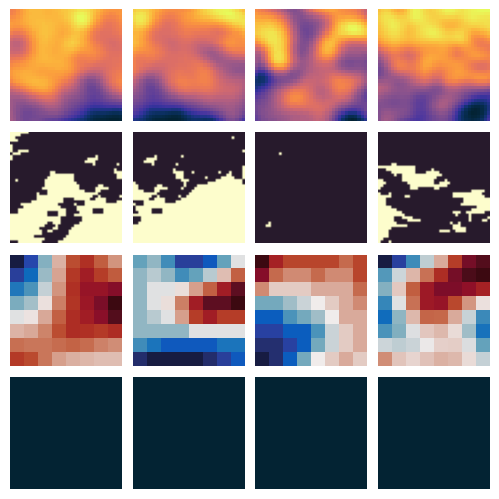

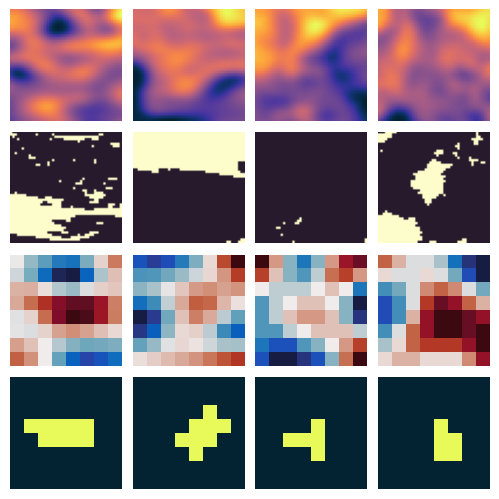

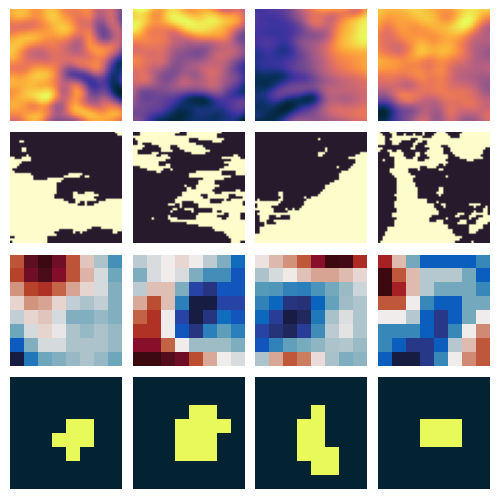

In [599]:
visualize_images_with(0, save_as="images_with_no_cyclone.png") # No eddy
visualize_images_with(1, save_as="images_with_cyclone.png") # Eddy
visualize_images_with(2, save_as="images_with_anticyclone.png") # Reverse eddy

# Visualize on map

In [600]:
# Print min/max lat/lon, used to center image
min_lat = np.round(min(map(lambda r: min(r), df_train["SST_LATITUDE"])))
max_lat = np.round(max(map(lambda r: max(r), df_train["SST_LATITUDE"])))
min_lon = np.round(min(map(lambda r: min(r), df_train["SST_LONGITUDE"])))
max_lon = np.round(max(map(lambda r: max(r), df_train["SST_LONGITUDE"])))

print(f"Min lat: {min_lat}\nMax lat: {max_lat}\nMin lon: {min_lon}\nMax lon: {max_lon}\n")

Min lat: 21.0
Max lat: 59.0
Min lon: 286.0
Max lon: 339.0



In [601]:
def images_on_map(data, categories: list[str], cm="viridis", alpha: list[float]=[0.8], mark_eddy_contour=False, mark_eddy_centre=False, limit: int = -1, save_as: str = None):
    plt.figure(figsize=(20, 10), )
    ax = plt.axes(projection=ccrs.PlateCarree())

    ax.set_global()
    ax.coastlines()

    # Images
    for j, category in enumerate(categories):
        for i, (_, row) in enumerate(data.iterrows()):
            if (limit >= 0 and i >= limit):
                break

            lats = [lat for lat in row[f"{category}_LATITUDE"]]
            lons = [lon for lon in row[f"{category}_LONGITUDE"]]
            lon2d, lat2d = np.meshgrid(lons, lats)

            ax.pcolormesh(
                lon2d,
                lat2d,
                row[category],
                transform=ccrs.PlateCarree(),
                cmap=cm,
                snap=True,
                alpha=alpha[j],
                shading="auto",
            )

            # Mark eddy contour
            if (mark_eddy_contour):
                if (not np.any(np.isnan(row["EDDY_LATITUDE"])) and not np.any(np.isnan(row["EDDY_LONGITUDE"]))):
                    ax.scatter(row["EDDY_LONGITUDE"], row["EDDY_LATITUDE"], color=(1, 0, 0, 0.05), s=1, transform=ccrs.PlateCarree(), zorder=5)
                
            # Mark eddy centre
            if (mark_eddy_centre):
                if (not np.any(np.isnan(row["EDDY_CENTRE"]))):
                    ax.scatter(row["EDDY_CENTRE"][0], row["EDDY_CENTRE"][1], color=(1, 0, 0, 0.5), s=1.0, transform=ccrs.PlateCarree(), zorder=5)

    zoom = 3
    ax.set_extent([
        286 - zoom, 339 + zoom,
        21 - zoom, 59 + zoom
    ], crs=ccrs.PlateCarree())

    if (save_as != None):
        plt.savefig(f"./figures/{save_as}", dpi=200, transparent=True, bbox_inches="tight", pad_inches=0)
    plt.show()

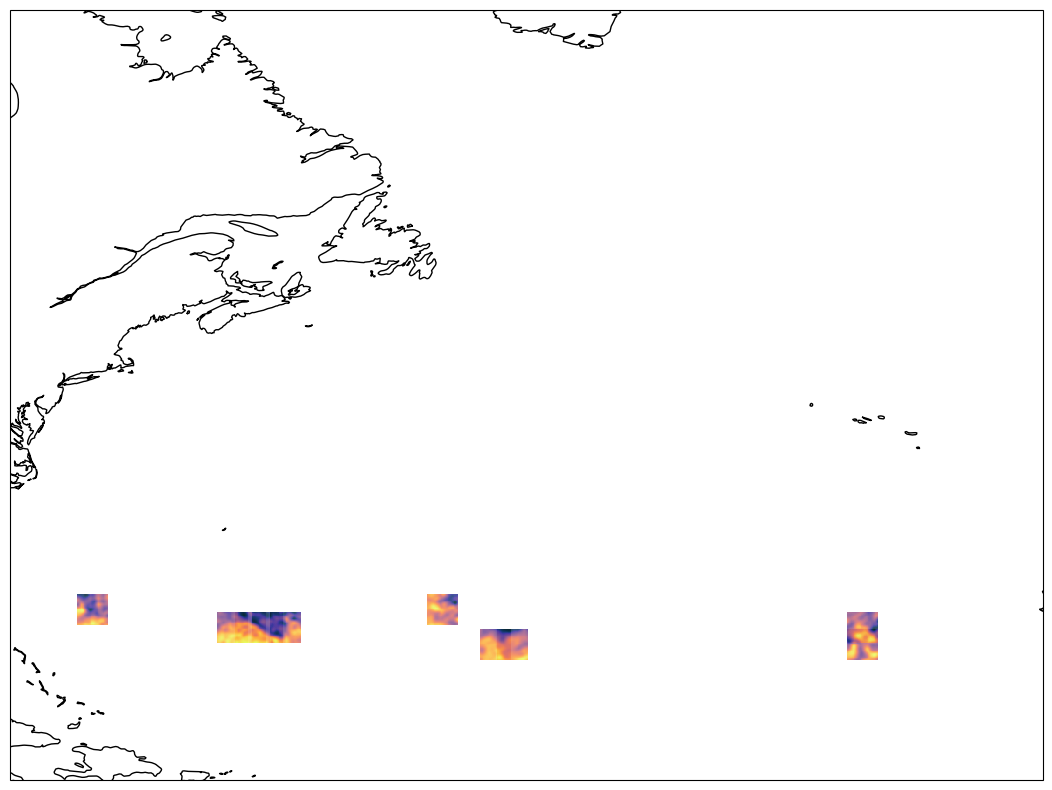

In [602]:
images_on_map(df_train, ["SST"], cm=cmocean.cm.thermal, alpha=[0.85], mark_eddy_centre=True, mark_eddy_contour=False, limit=10, save_as="sst_map_train.png")

<h1>Other</h1>    

In [603]:
# fig, axs = plt.subplots(5, 10)
# fig.subplots_adjust(left=0, bottom=0, right=1, top=1, wspace=0.1, hspace=-.7)

# random_i = [random.randint(0, len(df_train) - 1) for _ in range(0, 5)]
# random_j = [random.randint(0, 50) for _ in range(0, 10)]

# for i, axi in enumerate(axs):
#     for j, axj in enumerate(axi):
#         # Select image
#         image = df_train.iloc[random_i[i]]["SST"][random_j[j]]

#         # Border?
#         if df_train.iloc[random_i[i]]["LABELS"][random_j[j]] == 1:
#             rect = mpl.patches.Rectangle((0, 0), width=len(image), height=len(image[0]), fc="none", ec="lime", lw=3)
#             axj.add_patch(rect)
#         elif df_train.iloc[random_i[i]]["LABELS"][random_j[j]] == 2:
#             rect = mpl.patches.Rectangle((0, 0), width=len(image), height=len(image[0]), fc="none", ec="blue", lw=3)
#             axj.add_patch(rect)
        
#         # Image
#         axj.imshow(image, cmap="coolwarm")
#         axj.axis('off')
        
#         # # Text
#         # if i == 0: axj.set_title(f"Nr. {j + 1}", fontsize=10)
#         # if j == 0: axj.text(-0.2, 0.5, df_train.iloc[i + i_offset].name.strftime("%d.%m.%Y"), transform=axj.transAxes, va='center', ha='right')

# Select train and test

In [604]:
X_train = df_train[["SST", "CHLA"]]
y_train = df_train[["LABEL"]]

X_test = df_test[["SST", "CHLA"]]
y_test = df_test[["LABEL"]]

# Transformers

In [622]:
# Transformer: remove corrupt images (filter pixel sums above 93%)

def _factor(img, scaler):
    return np.sum(np.abs(scaler.transform(img.reshape(-1, 1))))

def _filter(data):
    data_c = data.copy()
    remove = []

    for category in data_c.columns:
        print("ok?")
        scaler = MinMaxScaler(feature_range=(-1, 1)).fit(np.concatenate(data_c[category].map(lambda img: img.flatten())).reshape(-1, 1))
        print("ok!")
        sorted_sums = sorted([_factor(img, scaler) for img in data[category].tolist()])
        limit = sorted_sums[int(len(sorted_sums) * 0.93)]
        remove.extend(data_c[data_c[category].map(lambda img: _factor(img, scaler)) > limit].index.values)

    data_c = data_c.drop(remove)

    return data_c

t_filter = FunctionTransformer(func=_filter)

In [606]:
# Transformer: resize images

def _crop(img, bounding): # https://stackoverflow.com/a/50322574
    start = tuple(map(lambda a, da: a//2-da//2, img.shape, bounding))
    end = tuple(map(operator.add, start, bounding))
    slices = tuple(map(slice, start, end))

    return img[slices]

def _resize(data):
    data_c = data.copy()

    min_size = min(np.concatenate(list(map(lambda a: list(map(lambda b: b.shape, a)), data.values))).flatten())
    min_shape = (min_size, min_size)

    for category in data_c.columns:
        data_c[category] = data_c[category].map(lambda img: _crop(img, min_shape))

    return data_c

t_resize = FunctionTransformer(func=_resize)

In [617]:
# Transformer: scale images

def _scale_image(img, scaler):
    shape = img.shape
    scaled = scaler.transform(img.reshape(-1, 1))

    return scaled.reshape(shape)
    

def _scale(data):
    data_c = data.copy()

    for category in data_c.columns:
        scaler = StandardScaler().fit(np.concatenate(data_c[category].map(lambda img: img.flatten())).reshape(-1, 1))
        data_c[category] = data_c[category].map(lambda img: _scale_image(img, scaler))

    return data_c

t_scale = FunctionTransformer(func=_scale)

# # Transformer: scale images

# def _scale_image(img, scaler=MinMaxScaler()):
#     shape = img.shape
#     scaled = scaler.fit_transform(img.reshape(-1, 1))

#     return scaled.reshape(shape)
    

# def _scale(data):
#     data_c = data.copy()

#     for category in data_c.columns:
#         data_c[category] = data_c[category].map(lambda img: _scale_image(img))

#     return data_c

# t_scale = FunctionTransformer(func=_scale)

In [608]:
# Transformer: into tensors

# Shape = (Sample, Channel, Height, Width)
def _add_tensors_x(data):
    data_c = data.copy()

    stacks = []
    for column in data_c.columns:
        stacked = np.stack(data_c[column].values)  # (N, H, W)
        stacks.append(stacked)

    # Stack (C, N, H, W)
    data_c = np.stack(stacks, axis=0)

    # Rearrange (N, C, H, W)
    data_c = np.transpose(data_c, (1, 0, 2, 3))
    data_c = torch.from_numpy(data_c).float()

    return data_c

t_tensors_x = FunctionTransformer(func=_add_tensors_x)

In [609]:
# Assumes LABEL
def _add_tensors_y(data):
    data_c = data.copy()

    flattened = [arr for arr in data_c["LABEL"]]
    data_c = torch.tensor(flattened, dtype=torch.long)

    return data_c

t_tensors_y = FunctionTransformer(func=_add_tensors_y)

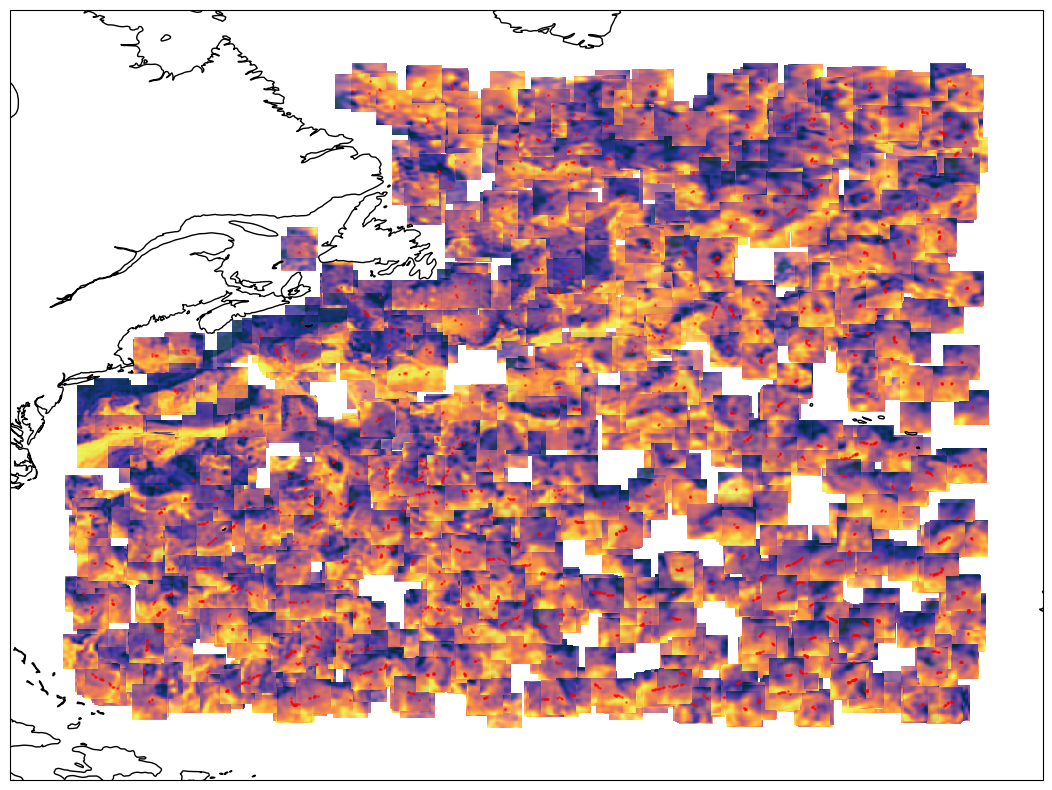

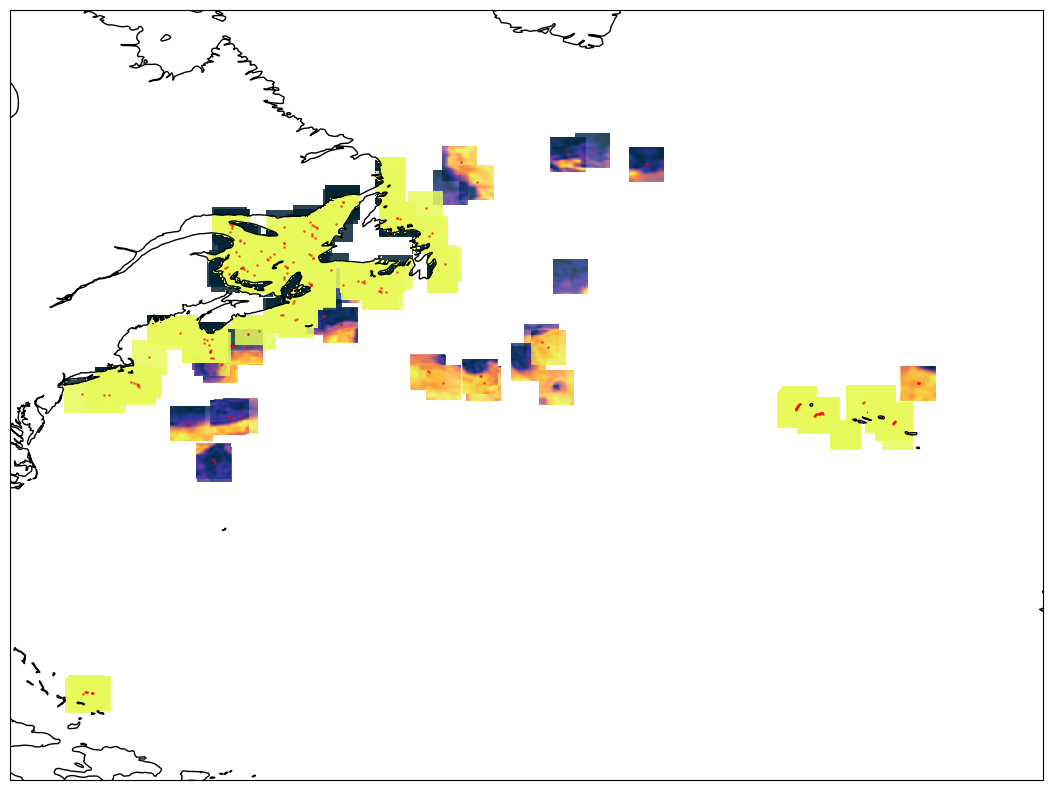

In [610]:
df_filtered = t_filter.set_output(transform="pandas").transform(X_train)

images_on_map(df_train.loc[df_filtered.index], ["SST"], cm=cmocean.cm.thermal, alpha=[0.85], mark_eddy_centre=True, mark_eddy_contour=False, limit=-1)
images_on_map(df_train.loc[list(set(X_train.index.values) - set(df_filtered.index.values))], ["SST"], cm=cmocean.cm.thermal, alpha=[0.85], mark_eddy_centre=True, mark_eddy_contour=False, limit=-1)

# Convolution neural network

In [611]:
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        # Input to hidden layer
        self.i2h = nn.Sequential(
            nn.Conv2d(2, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        # 1st (convolution) hidden layer
        self.h1 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        # 2nd (convolution) hidden layer
        self.h2 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
        )

        # 3rd (fully connected) hidden layer
        self.h3 = nn.Sequential(
            nn.LazyLinear(256),
            nn.ReLU(),
            nn.Dropout(0.2),
        )

        # 4th (fully connected) hidden layer
        self.h4 = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
        )

        # Hidden layer to output
        self.h2o = nn.Linear(128, 3)

    def forward(self, x):
        out = self.i2h(x)
        #print(f"i2h: {out.shape}")
        out = self.h1(out)
        #print(f"h1: {out.shape}")
        out = self.h2(out)
        #print(f"h2: {out.shape}")
        out = out.view(out.shape[0], -1)
        #print(f"After view {out.shape}")
        out = self.h3(out)
        #print(f"h3: {out.shape}")
        out = self.h4(out)
        #print(f"h4: {out.shape}")
        out = self.h2o(out)
        #print(f"h2o: {out.shape}")

        return out


<h1>Pipeline</h1>

In [612]:
pipeline = Pipeline([
    ("scale", t_scale.set_output(transform="pandas")),
    # ("filter", t_filter.set_output(transform="pandas")),
    ("resize", t_resize.set_output(transform="pandas")),
    ("tensors", t_tensors_x),
    ("classification", NeuralNetClassifier(
        CNN(),
        criterion=nn.CrossEntropyLoss,
        optimizer=torch.optim.Adam,
        lr=0.01,
        max_epochs=30,
        iterator_train__shuffle=True,
        verbose=10
    )),
])

<h1>Train</h1>

In [ ]:
index = t_filter.transform(X_train).index

X_train = X_train.drop(index=X_train.index.difference(index))
y_train = y_train.drop(index=y_train.index.difference(index))

#y_train_index = t_filter.transform(X_train).index.intersection(y_train.index)
pipeline.fit(X_train, t_tensors_y.transform(y_train))

ok?


KeyError: 39

# Visualize loss

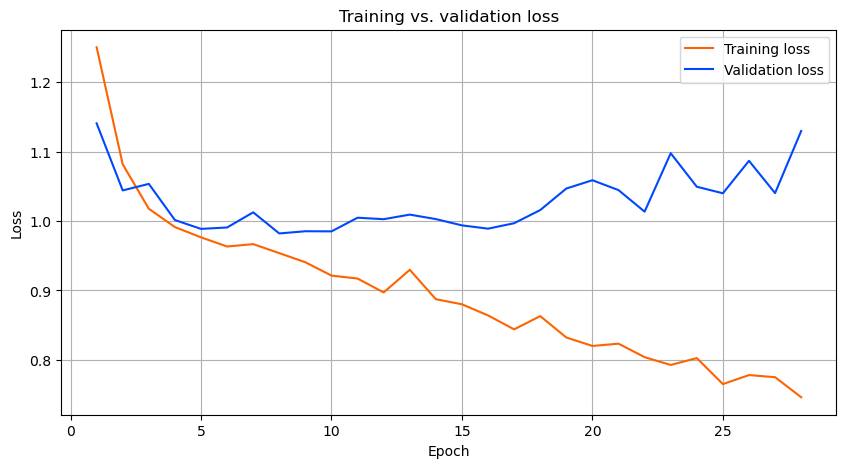

In [554]:
def visualize_loss(pipeline):
    df_loss = pd.DataFrame(
        list(map(lambda v: [v["epoch"], v["train_loss"], v["valid_loss"]], pipeline.steps[-1][1].history[0:-2]))
    ).rename(columns={ 0: "Epoch", 1: "Training loss", 2: "Validation loss"})

    plt.subplots(figsize=(10, 5))
    plt.plot(df_loss["Epoch"], df_loss["Training loss"], c=RED, label="Training loss")
    plt.plot(df_loss["Epoch"], df_loss["Validation loss"], c=BLUE, label="Validation loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Training vs. validation loss")
    plt.legend()
    plt.grid()
    plt.show()

visualize_loss(pipeline)

# Visualize predictions

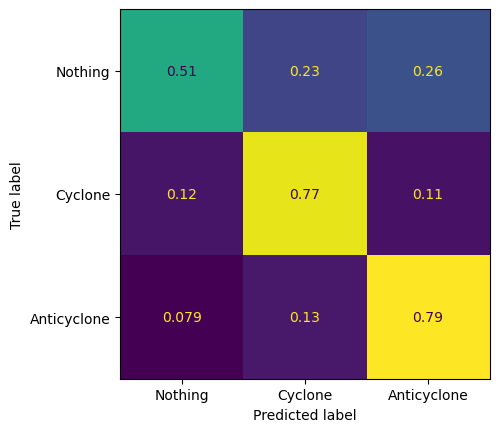

In [574]:
y_train_index = t_filter.transform(X_train).index.intersection(y_train.index)
y_true = list(map(lambda v: v[0], y_train.loc[y_train_index].values))
y_pred = pipeline.predict(X_train)

_ = ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=["Nothing", "Cyclone", "Anticyclone"], normalize="true", colorbar=False)

In [556]:
y_test

,LABEL
0,0
1,0
2,0
3,0
4,0
...,...
4194,2
4195,2
4196,2
4197,2


In [557]:
len(y_pred)

4504

In [558]:
len(y_train_index)

4504

In [559]:
pipeline.predict(X_train)

array([1, 1, 1, ..., 2, 2, 2], shape=(4504,))

In [560]:
pipeline.predict(X_test)

array([2, 2, 0, ..., 0, 1, 2], shape=(3893,))

In [561]:
len(y_true)

4504

In [562]:
len(X_test)

4199

In [563]:
t_filter.transform(X_test).index.intersection(y_test.index)

Index([   0,    1,    2,    3,    4,    5,    6,    7,    8,    9,
       ...
       4188, 4189, 4190, 4191, 4192, 4193, 4194, 4195, 4196, 4198],
      dtype='int64', length=4042)

In [575]:
y_test_index = t_filter.transform(X_test).index.intersection(y_test.index)
y_true = list(map(lambda v: v[0], y_test.loc[y_test_index].values))
y_pred = pipeline.predict(X_test)

_ = ConfusionMatrixDisplay.from_predictions(y_true, y_pred, display_labels=["Nothing", "Cyclone", "Anticyclone"])

ValueError: Found input variables with inconsistent numbers of samples: [4042, 3893, 4042]

# Metrics

In [ ]:
class Metrics:
    def __init__(self, model, X, y, cross_validated=True):
        self.cross_validated = cross_validated
        self.measurements = [
            ["Mean Absolute Percentage Error", "neg_mean_absolute_percentage_error", mean_absolute_percentage_error],
            ["Median Absolute Error", "neg_median_absolute_error", median_absolute_error],
            ["R2", "r2", r2_score],
        ]

        if (self.cross_validated):
            self._metrics = list(map(lambda kv: (
                kv[0],
                np.mean(cross_val_score(model, X, y, scoring=kv[1]
            ))), self.measurements))
        else:
            self._metrics = list(map(lambda kv: (
                kv[0],
                kv[2](y, model.predict(X))
            ), self.measurements))

    def __repr__(self):
        if self.cross_validated: return '\n'.join(map(lambda kv: f"{kv[0]} (CV): {np.abs(kv[1]):.5f}", self._metrics))
        else: return '\n'.join(map(lambda kv: f"{kv[0]}: {np.abs(kv[1]):.5f}", self._metrics))

<h1>Conclusion</h1>

<p>
...
</p>

<h1>References</h1>

<p>[1] Authors. Title. Name. (Year). <a href="https://www.example.com" target="_blank">https://www.example.com/</a> (Accessed online: date)</p>

<p>[1] Dennis G Wilson, Mercator Hackathon, Simon van Gennip, and svangennip. Ocean Eddy Identification. Kaggle. (2022). <a href="https://www.kaggle.com/competitions/mercatorocean" target="_blank">https://www.kaggle.com/competitions/mercatorocean/data</a> (Accessed online: 20.04.2026)</p>